# Introduction to Ensemble Learning

Ensemble Learning is a machine learning technique in which multiple models are combined to improve the overall performance of prediction.

Instead of using only one model, ensemble learning uses a group of models and combines their outputs to produce better accuracy, stability, and robustness.

## Simple Idea
If one model makes mistakes, other models can help correct those mistakes.

## Real Life Example
Suppose 5 students solve the same problem.
If one student gives a wrong answer but the other 4 give the correct answer, then the final answer is more likely to be correct.

This is the basic idea of ensemble learning.

# Why Use Ensemble Learning?

Ensemble learning is used because:

1. It improves prediction accuracy.
2. It reduces overfitting.
3. It increases model stability.
4. It performs better than a single model in many cases.
5. It combines the strengths of different models.

## Main Goal
To create a stronger model by combining weaker or multiple models.

# Types of Ensemble Learning

There are mainly three important types of ensemble methods:

## 1. Bagging
- Full form: Bootstrap Aggregating
- Multiple models are trained independently on different random samples of data.
- Final output is taken by averaging or voting.
- Example: Random Forest

## 2. Boosting
- Models are trained one after another.
- Each new model focuses on correcting the errors of the previous model.
- Example: AdaBoost, Gradient Boosting, XGBoost

## 3. Stacking
- Multiple different models are trained.
- Their predictions are used as input to another model called meta-model.
- The meta-model gives the final output.

In [1]:
# Importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dataset Used

In this notebook, we will use the Iris dataset.

## About Iris Dataset
It is a famous machine learning dataset containing flower information.

### Features:
- Sepal length
- Sepal width
- Petal length
- Petal width

### Target Classes:
- Setosa
- Versicolor
- Virginica

In [2]:
# Load dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Shape of X: (150, 4)
Shape of y: (150,)


In [3]:
# Convert dataset into DataFrame for better understanding

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


# Baseline Model

Before applying ensemble learning, let us first train a single Decision Tree model.

This will help us compare how ensemble methods improve performance.

In [5]:
# Single Decision Tree model

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


# 1. Bagging

Bagging means training multiple models independently using different random subsets of the training data.

Each model learns separately, and the final output is decided by:
- Majority voting (for classification)
- Averaging (for regression)

## Key Idea
Reduce variance and improve stability.

## Example
Random Forest is a famous bagging-based model.

In [6]:
# Bagging Classifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
    random_state=42
)

bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bagging))

Bagging Accuracy: 1.0


# 2. Random Forest

Random Forest is an advanced bagging technique.

It creates many decision trees using random subsets of:
- Training samples
- Features

Then it combines the predictions of all trees.

## Advantages
- High accuracy
- Handles overfitting better than a single tree
- Works well on many datasets

In [7]:
# Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


# 3. Boosting

Boosting trains models sequentially.

Each next model tries to correct the mistakes made by the previous model.

## Key Idea
Convert weak learners into a strong learner.

## Popular Boosting Algorithms
- AdaBoost
- Gradient Boosting
- XGBoost

# AdaBoost

AdaBoost stands for Adaptive Boosting.

It gives more importance to wrongly classified points, so that the next model focuses more on them.

## Features
- Sequential learning
- Improves weak learners
- Commonly uses decision stumps (small decision trees)

In [8]:
# AdaBoost Classifier

ada_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))

AdaBoost Accuracy: 0.9333333333333333


# Gradient Boosting

Gradient Boosting is another boosting method.

In this method, each new model tries to reduce the errors made by the previous models using gradient descent-like optimization.

## Features
- Powerful boosting technique
- Often gives very good results
- Can be slower than bagging methods

In [9]:
# Gradient Boosting Classifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 1.0


# 4. Voting Ensemble

Voting combines predictions from multiple different models.

There are two types:

## Hard Voting
The final class is selected by majority vote.

## Soft Voting
The final class is selected using average probabilities of all models.

Voting is useful when different models perform differently and we want to combine their strengths.

In [10]:
# Voting Classifier

model1 = LogisticRegression(max_iter=200)
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model3 = KNeighborsClassifier()

voting_model = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('rf', model2),
        ('knn', model3)
    ],
    voting='hard'
)

voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_voting))

Voting Classifier Accuracy: 1.0


# 5. Stacking

Stacking combines multiple base models and then uses another model called a meta-model to make the final prediction.

## How it works
1. Train multiple base models.
2. Get predictions from these models.
3. Use those predictions as input for a final model.
4. Final model produces the output.

## Benefit
Can capture the strengths of different algorithms.

In [11]:
# Stacking Classifier

base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('svc', SVC(probability=True, random_state=42))
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)

stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)

print("Stacking Classifier Accuracy:", accuracy_score(y_test, y_pred_stacking))

Stacking Classifier Accuracy: 1.0


# Comparing All Models

Now we will compare the accuracy of:
- Decision Tree
- Bagging
- Random Forest
- AdaBoost
- Gradient Boosting
- Voting
- Stacking

In [12]:
# Compare all accuracies

results = {
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Bagging': accuracy_score(y_test, y_pred_bagging),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'AdaBoost': accuracy_score(y_test, y_pred_ada),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gb),
    'Voting': accuracy_score(y_test, y_pred_voting),
    'Stacking': accuracy_score(y_test, y_pred_stacking)
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df

,Model,Accuracy
0,Decision Tree,1.000000
1,Bagging,1.000000
2,Random Forest,1.000000
3,AdaBoost,0.933333
4,Gradient Boosting,1.000000
5,Voting,1.000000
6,Stacking,1.000000


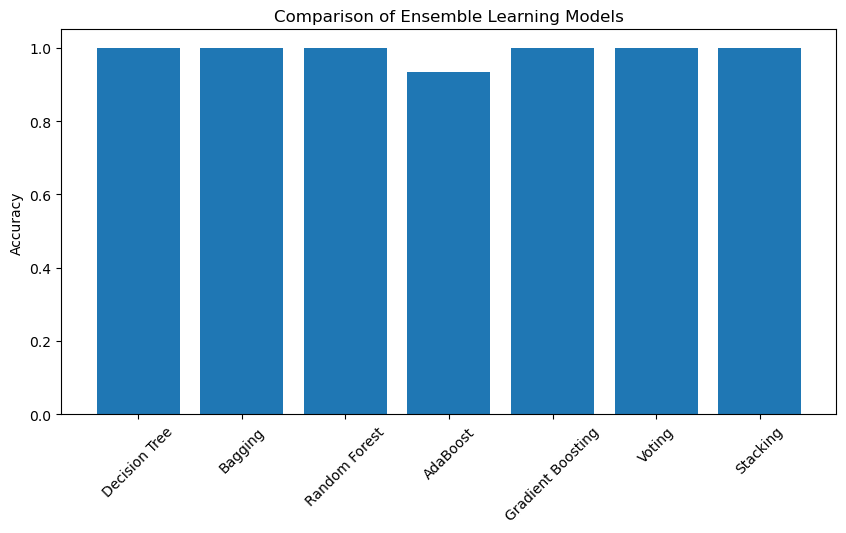

In [13]:
# Plot accuracy comparison

plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Comparison of Ensemble Learning Models")
plt.show()

# Classification Report of Best Model

Now let us print the classification report of one of the best-performing ensemble models.
Here we use Random Forest as an example.

In [14]:
# Classification report for Random Forest

print("Classification Report for Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n")
print(cm)# Difference Between Bagging and Boosting

| Feature | Bagging | Boosting |
|--------|--------|---------|
| Training style | Parallel | Sequential |
| Main goal | Reduce variance | Reduce bias |
| Model dependency | Independent models | Dependent models |
| Speed | Faster | Slower |
| Example | Random Forest | AdaBoost, Gradient Boosting |

## In Simple Words
- Bagging = build many models separately
- Boosting = build models one by one and improve mistakes

# Advantages of Ensemble Learning

1. Higher accuracy than single models
2. Better generalization
3. Reduces overfitting
4. More robust predictions
5. Works well in real-world machine learning tasks

# Disadvantages of Ensemble Learning

1. More complex than single models
2. Takes more training time
3. Harder to interpret
4. Requires more computational power
5. Debugging is more difficult

# Applications of Ensemble Learning

Ensemble learning is used in many real-life fields such as:

- Medical diagnosis
- Spam email detection
- Fraud detection
- Stock market prediction
- Recommendation systems
- Image classification
- Customer churn prediction

# Small Revision Notes

## Ensemble Learning
Combination of multiple machine learning models to improve performance.

## Bagging
Models are trained independently on random subsets of data.
Example: Random Forest

## Boosting
Models are trained sequentially and each tries to correct previous errors.
Example: AdaBoost, Gradient Boosting

## Voting
Combines predictions of different models using voting.

## Stacking
Uses predictions of multiple base models and combines them through a meta-model.

# Conclusion

Ensemble Learning is one of the most powerful techniques in machine learning.

It helps improve:
- Accuracy
- Stability
- Robustness

In this notebook, we studied:
- What ensemble learning is
- Why it is used
- Types of ensemble methods
- Practical implementation of Bagging, Random Forest, AdaBoost, Gradient Boosting, Voting, and Stacking

Hence, ensemble learning is very useful when we want better results than a single model.

# Final Summary

Ensemble learning means combining multiple models to get better results.

### Main Methods
- Bagging
- Boosting
- Voting
- Stacking

### Best Known Examples
- Random Forest
- AdaBoost
- Gradient Boosting

### Final Benefit
A group of models often performs better than a single model.

# Example in Very Simple Words

Suppose three friends are predicting whether it will rain tomorrow.

- Friend 1 says: Yes
- Friend 2 says: Yes
- Friend 3 says: No

Majority says "Yes", so the final answer becomes "Yes".

This is similar to ensemble learning:
many models together make a final decision.